In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Basic libraries imported successfully!")

Basic libraries imported successfully!


In [11]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.22.0-rc0


In [12]:
import os
dataset_path = r"D:\plantvillage dataset\color"

print("Dataset path:")
print(dataset_path)

Dataset path:
D:\plantvillage dataset\color


In [13]:
classes = os.listdir(dataset_path)

print("Total folders/classes:", len(classes))

for folder in classes:
    print(folder)

Total folders/classes: 38
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___healthy
Cherry_(including_sour)___Powdery_mildew
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___healthy
Corn_(maize)___Northern_Leaf_Blight
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___healthy
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___healthy
Potato___Late_blight
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___healthy
Strawberry___Leaf_scorch
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___healthy
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_mosaic_virus
Tomato___Tomato_Yellow_Leaf_C

In [14]:
plants = [
    "Apple",
    "Corn_(maize)",
    "Potato",
    "Tomato"
]

selected_classes = [
    folder for folder in classes
    if any(folder.startswith(plant + "___") for plant in plants)
]

selected_classes = sorted(selected_classes)

print("Selected classes:\n")

for folder in selected_classes:
    print(folder)

print("\nTotal selected classes:", len(selected_classes))

Selected classes:

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy

Total selected classes: 21


In [15]:
class_counts = {}

for class_name in selected_classes:
    class_path = os.path.join(dataset_path, class_name)
    
    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    
    class_counts[class_name] = len(image_files)

class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

class_counts_df

,Class,Number of Images
0,Apple___Apple_scab,630
1,Apple___Black_rot,621
2,Apple___Cedar_apple_rust,275
3,Apple___healthy,1645
4,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,513
5,Corn_(maize)___Common_rust_,1192
6,Corn_(maize)___Northern_Leaf_Blight,985
7,Corn_(maize)___healthy,1162
8,Potato___Early_blight,1000
9,Potato___Late_blight,1000


In [16]:



total_images = class_counts_df["Number of Images"].sum()

print("Total images used in our project:", total_images)

Total images used in our project: 27335


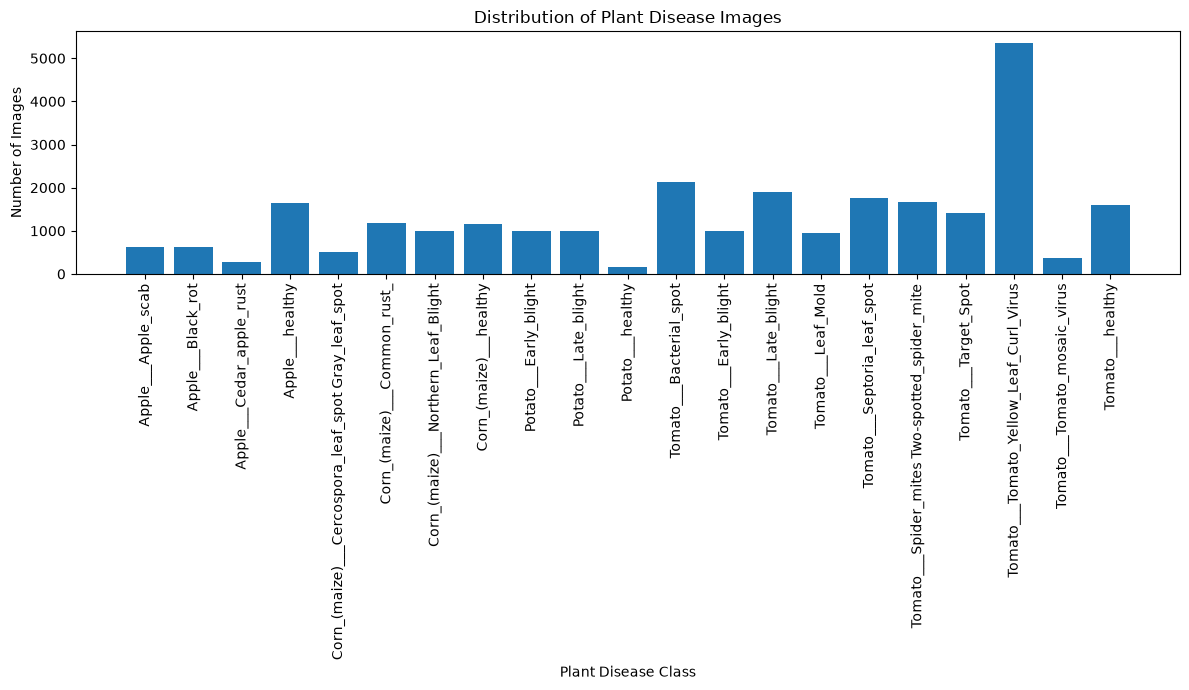

In [17]:
plt.figure(figsize=(12, 7))

plt.bar(
    class_counts_df["Class"],
    class_counts_df["Number of Images"]
)

plt.xticks(rotation=90)
plt.xlabel("Plant Disease Class")
plt.ylabel("Number of Images")
plt.title("Distribution of Plant Disease Images")

plt.tight_layout()
plt.show()

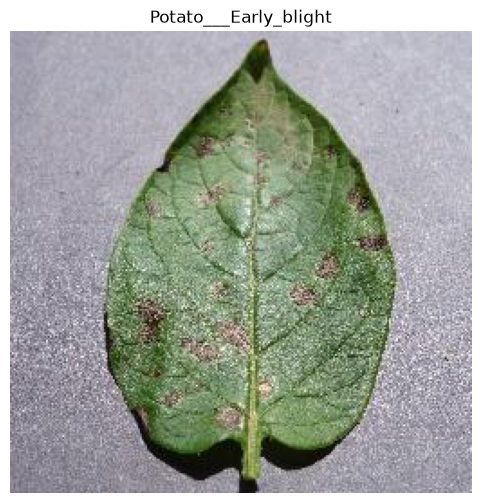

In [18]:
import random
from PIL import Image

random_class = random.choice(selected_classes)

class_path = os.path.join(dataset_path, random_class)

image_files = [
    file for file in os.listdir(class_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

random_image = random.choice(image_files)

image_path = os.path.join(class_path, random_image)

image = Image.open(image_path)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(random_class)

plt.show()

In [19]:
print("Original image size:", image.size)

Original image size: (256, 256)


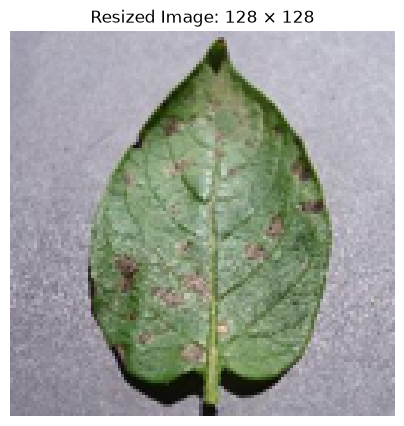

In [20]:
IMG_SIZE = 128

resized_image = image.resize((IMG_SIZE, IMG_SIZE))

plt.figure(figsize=(5, 5))
plt.imshow(resized_image)
plt.axis("off")
plt.title("Resized Image: 128 × 128")

plt.show()

In [21]:
image_paths = []
labels = []

for class_name in selected_classes:
    
    class_path = os.path.join(dataset_path, class_name)
    
    for file in os.listdir(class_path):
        
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            
            image_paths.append(
                os.path.join(class_path, file)
            )
            
            labels.append(class_name)

print("Total images:", len(image_paths))
print("Total labels:", len(labels))

Total images: 27335
Total labels: 27335


In [22]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

encoded_labels = label_encoder.fit_transform(labels)

print("Class mapping:")

for number, class_name in enumerate(label_encoder.classes_):
    print(number, "=", class_name)

Class mapping:
0 = Apple___Apple_scab
1 = Apple___Black_rot
2 = Apple___Cedar_apple_rust
3 = Apple___healthy
4 = Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
5 = Corn_(maize)___Common_rust_
6 = Corn_(maize)___Northern_Leaf_Blight
7 = Corn_(maize)___healthy
8 = Potato___Early_blight
9 = Potato___Late_blight
10 = Potato___healthy
11 = Tomato___Bacterial_spot
12 = Tomato___Early_blight
13 = Tomato___Late_blight
14 = Tomato___Leaf_Mold
15 = Tomato___Septoria_leaf_spot
16 = Tomato___Spider_mites Two-spotted_spider_mite
17 = Tomato___Target_Spot
18 = Tomato___Tomato_Yellow_Leaf_Curl_Virus
19 = Tomato___Tomato_mosaic_virus
20 = Tomato___healthy


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    encoded_labels,
    test_size=0.20,
    random_state=42,
    stratify=encoded_labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

Training images: 21868
Validation images: 2733
Testing images: 2734


In [26]:
def load_images(image_paths, labels):
    
    images = []
    
    for path in image_paths:
        
        img = Image.open(path).convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE))
        
        img = np.array(img)
        
        images.append(img)
    
    images = np.array(images, dtype=np.float32)
    
    # Normalize pixel values
    images = images / 255.0
    
    labels = np.array(labels)
    
    return images, labels

In [27]:
X_train_img, y_train = load_images(X_train, y_train)

print("Training data shape:", X_train_img.shape)
print("Training labels shape:", y_train.shape)

Training data shape: (21868, 128, 128, 3)
Training labels shape: (21868,)


In [29]:
X_val_img, y_val = load_images(X_val, y_val)

X_test_img, y_test = load_images(X_test, y_test)

print("Validation shape:", X_val_img.shape)
print("Test shape:", X_test_img.shape)

Validation shape: (2733, 128, 128, 3)
Test shape: (2734, 128, 128, 3)


In [30]:
from tensorflow.keras import models, layers

num_classes = len(label_encoder.classes_)

model = models.Sequential([
    
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    
    layers.Dense(128, activation="relu"),
    
    layers.Dropout(0.5),
    
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

D:\anacoda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 21)                  │           2,709 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,307,349 (12.62 MB)

 Trainable params: 3,307,349 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [38]:
history = model.fit(
    X_train_img,
    y_train,
    validation_data=(X_val_img, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
684/684 ━━━━━━━━━━━━━━━━━━━━ 285s 416ms/step - accuracy: 0.7509 - loss: 0.7589 - val_accuracy: 0.8079 - val_loss: 0.5795
Epoch 2/10
684/684 ━━━━━━━━━━━━━━━━━━━━ 332s 485ms/step - accuracy: 0.8007 - loss: 0.5955 - val_accuracy: 0.8793 - val_loss: 0.3967
Epoch 3/10
684/684 ━━━━━━━━━━━━━━━━━━━━ 298s 435ms/step - accuracy: 0.8335 - loss: 0.4886 - val_accuracy: 0.8858 - val_loss: 0.3675
Epoch 4/10
684/684 ━━━━━━━━━━━━━━━━━━━━ 297s 434ms/step - accuracy: 0.8562 - loss: 0.4187 - val_accuracy: 0.8902 - val_loss: 0.3606
Epoch 5/10
684/684 ━━━━━━━━━━━━━━━━━━━━ 329s 481ms/step - accuracy: 0.8810 - loss: 0.3537 - val_accuracy: 0.9012 - val_loss: 0.3330
Epoch 6/10
684/684 ━━━━━━━━━━━━━━━━━━━━ 339s 495ms/step - accuracy: 0.8900 - loss: 0.3203 - val_accuracy: 0.9008 - val_loss: 0.3360
Epoch 7/10
684/684 ━━━━━━━━━━━━━━━━━━━━ 294s 430ms/step - accuracy: 0.9032 - loss: 0.2845 - val_accuracy: 0.9140 - val_loss: 0.3262
Epoch 8/10
684/684 ━━━━━━━━━━━━━━━━━━━━ 311s 455ms/step - accuracy: 0.9123 -

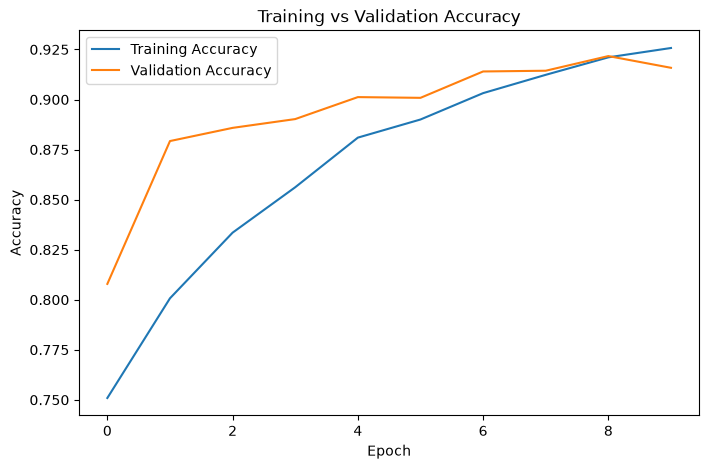

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

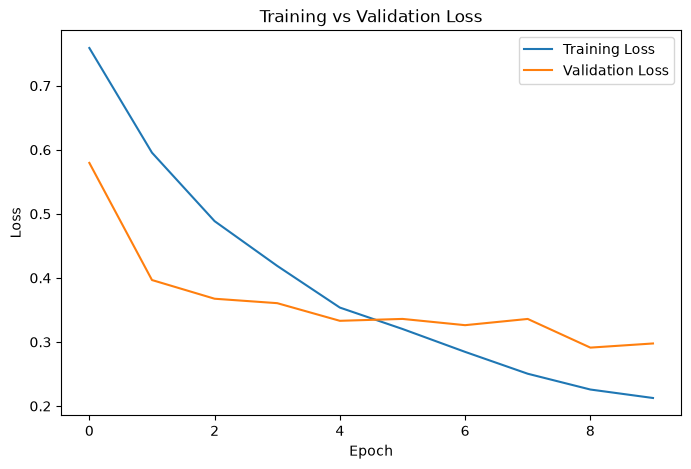

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [41]:
test_loss, test_accuracy = model.evaluate(
    X_test_img,
    y_test
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9155 - loss: 0.2809
Test Accuracy: 0.9155083894729614
Test Loss: 0.2809213697910309


In [42]:
y_probability = model.predict(X_test_img)

y_pred = np.argmax(y_probability, axis=1)

print("Predictions generated successfully!")

86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step
Predictions generated successfully!


In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.93      0.68      0.79        63
                                 Apple___Black_rot       0.97      0.92      0.94        62
                          Apple___Cedar_apple_rust       0.89      0.89      0.89        27
                                   Apple___healthy       0.88      0.96      0.92       165
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.83      0.67      0.74        51
                       Corn_(maize)___Common_rust_       0.99      1.00      1.00       119
               Corn_(maize)___Northern_Leaf_Blight       0.84      0.92      0.88        99
                            Corn_(maize)___healthy       1.00      1.00      1.00       116
                             Potato___Early_blight       0.92      0.94      0.93       100
                              Potato___Late_blight       0.78      0.91      0.

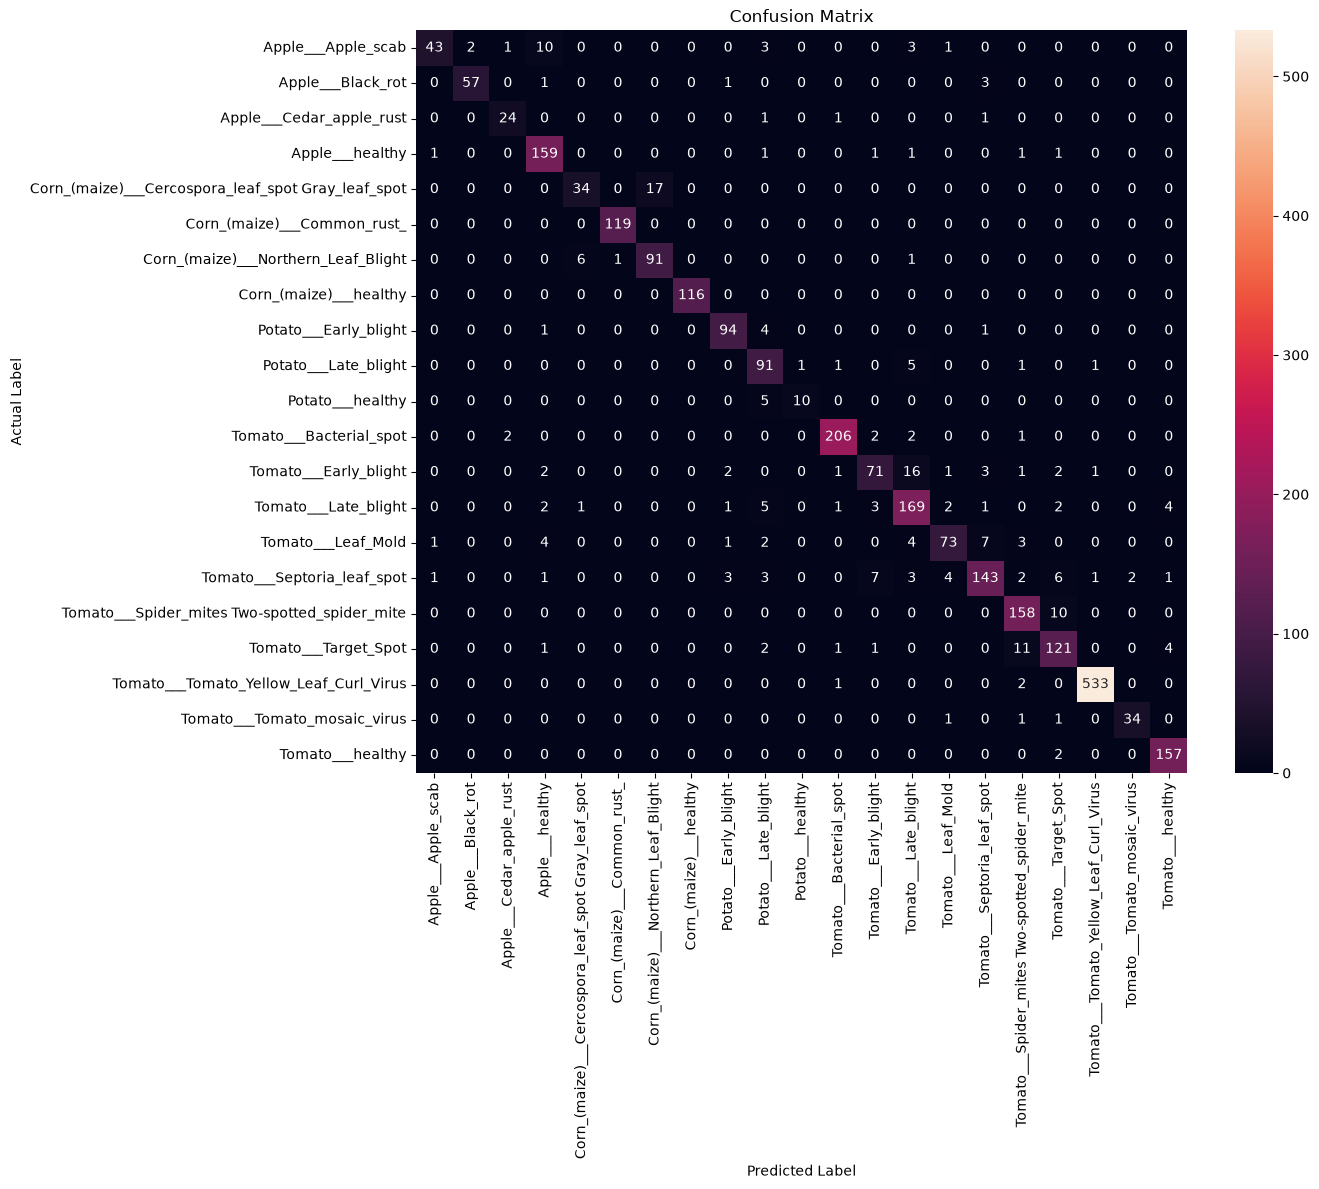

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

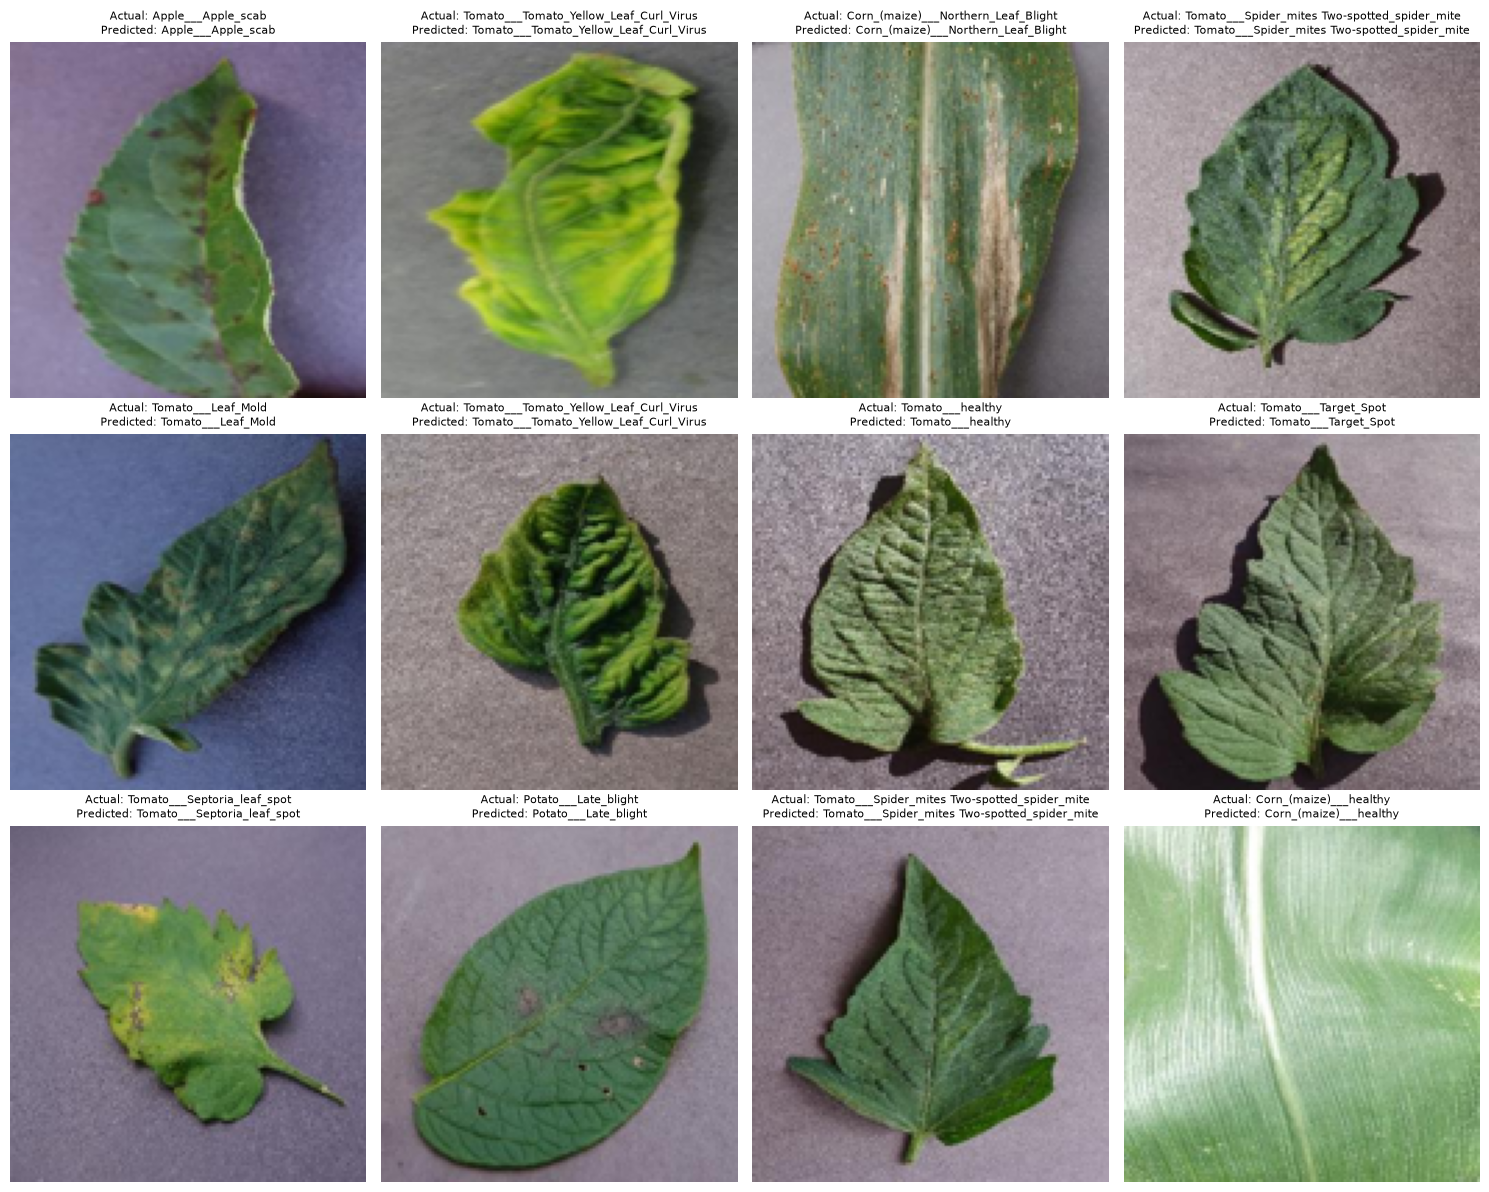

In [45]:
plt.figure(figsize=(15, 12))

for i in range(12):
    
    plt.subplot(3, 4, i + 1)
    
    plt.imshow(X_test_img[i])
    
    actual = label_encoder.inverse_transform([y_test[i]])[0]
    predicted = label_encoder.inverse_transform([y_pred[i]])[0]
    
    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        fontsize=8
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [46]:
model.save("plant_disease_cnn.keras")

print("CNN model saved successfully!")

CNN model saved successfully!


In [47]:
import joblib

joblib.dump(
    label_encoder,
    "plant_disease_label_encoder.pkl"
)

print("Label encoder saved successfully!")

Label encoder saved successfully!


In [48]:
new_image_path = r"C:\Users\AASHTHA\Downloads\my_leaf.jpg"

img = Image.open(new_image_path).convert("RGB")

img = img.resize((IMG_SIZE, IMG_SIZE))

img_array = np.array(img, dtype=np.float32)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class_index = np.argmax(prediction)

predicted_class = label_encoder.inverse_transform(
    [predicted_class_index]
)[0]

confidence = np.max(prediction) * 100

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.show()

print("Predicted Disease/Class:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\AASHTHA\\Downloads\\my_leaf.jpg'